# Imports Needed

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading and Exploration

In [35]:
#Data Loading and Exploring
df = pd.read_csv('cleaned_data.csv')
df.head(5)

,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged
0,Los sitios web seguros .gov usan HTTPSUn canda...,Will the use of HTTPS on .gov websites be mand...,The US government has not announced a specific...,hallucinated,Outdated information hallucination,Out-of-scope information,Other hallucination
1,Experience Cloud uses the following hosts to d...,What specific domains should be allowed throug...,Adobe Experience Cloud uses the following host...,hallucinated,Incompleteness hallucination,Out-of-scope information,Other hallucination
2,Alzheimer's disease and related dementias (AD/...,What specific breakthroughs in Alzheimer's tre...,"Based on current NIH research initiatives, sev...",hallucinated,Overclaim hallucination,Out-of-scope information,Other hallucination
3,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","What organization has accredited A.D.A.M., Inc...","A.D.A.M., Inc. is accredited by the Atlantis H...",hallucinated,Entity-error hallucination,Default question type,Entity-error hallucination
4,"""This dataset for NOAA's Science On a Sphere d...",What type of educational activity is encourage...,The dataset encourages learners to complete a ...,hallucinated,Relation-error hallucination,Default question type,Relation-error hallucination


In [36]:
df.shape

(9988, 7)

In [37]:
df["label"].value_counts()

label
factual         5971
hallucinated    4017
Name: count, dtype: int64

<Axes: xlabel='label'>

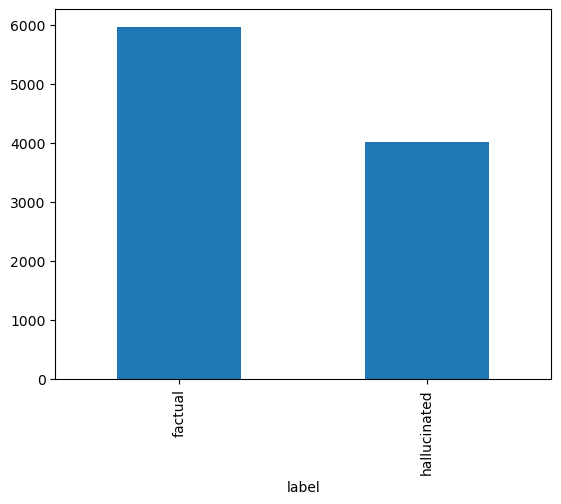

In [38]:
df["label"].value_counts().plot(kind="bar")

In [39]:
df.isnull().sum()

reference                           0
input                               0
output                              0
label                               0
hallucination_type_realized      5971
question_type                       0
hallucination_type_encouraged       0
dtype: int64

In [40]:
df["is_hallucination"] = (df["label"] == "hallucinated").astype(int)

### Hallucination Counts by Question Type

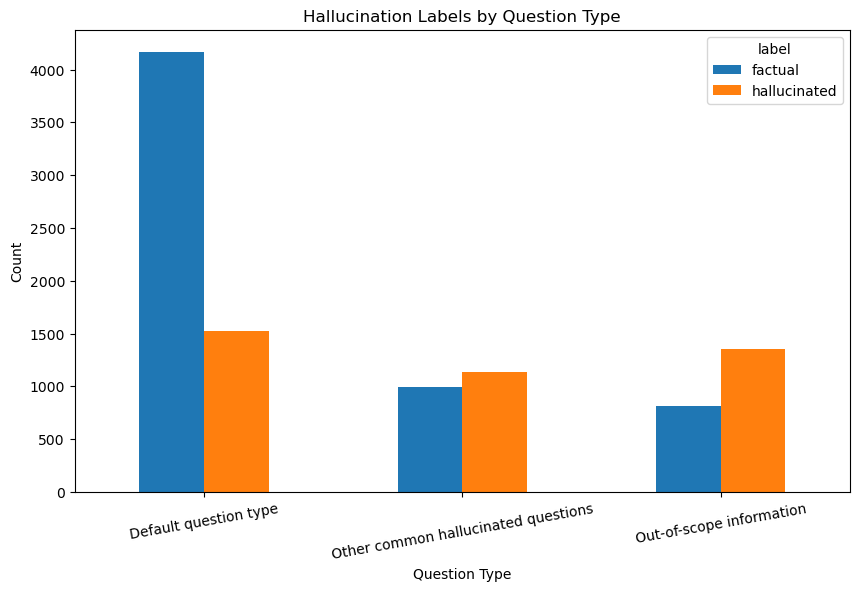

In [41]:
question_counts = pd.crosstab(
    df["question_type"],
    df["label"])

question_counts.plot(
    kind="bar",
    figsize=(10,6))

plt.title("Hallucination Labels by Question Type")

plt.xlabel("Question Type")
plt.ylabel("Count")

plt.xticks(rotation=10)

plt.show()

### Hallucination Types Count

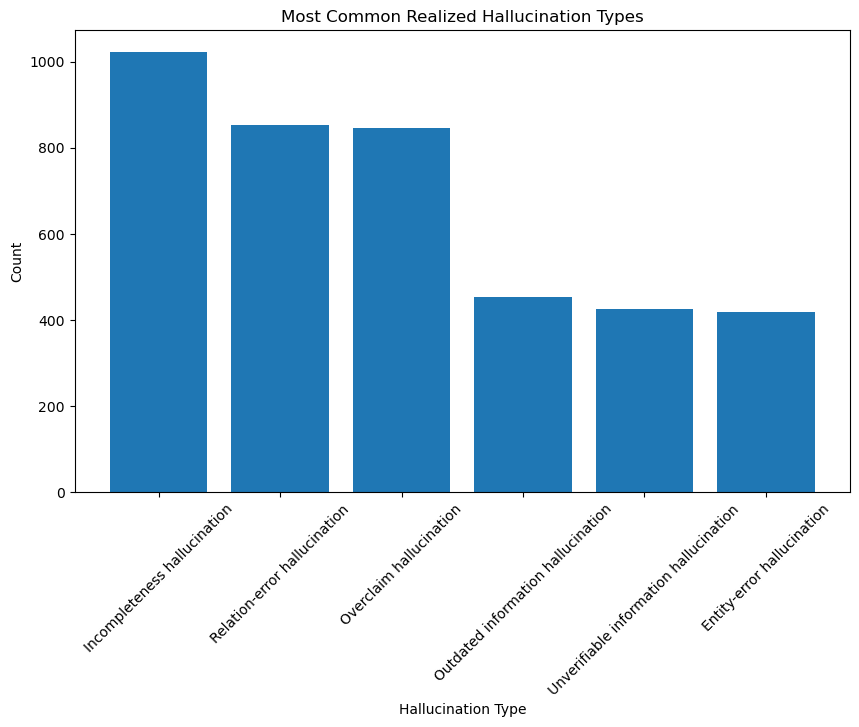

In [42]:
hallucination_counts = (df["hallucination_type_realized"].value_counts())

plt.figure(figsize=(10,6))

plt.bar(
    hallucination_counts.index,
    hallucination_counts.values
)

plt.title("Most Common Realized Hallucination Types")

plt.xlabel("Hallucination Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Hallucination Types Across Question Types

This graph could tell us which prompt/condition a specific hallucination type is more visible at and most likely occur.

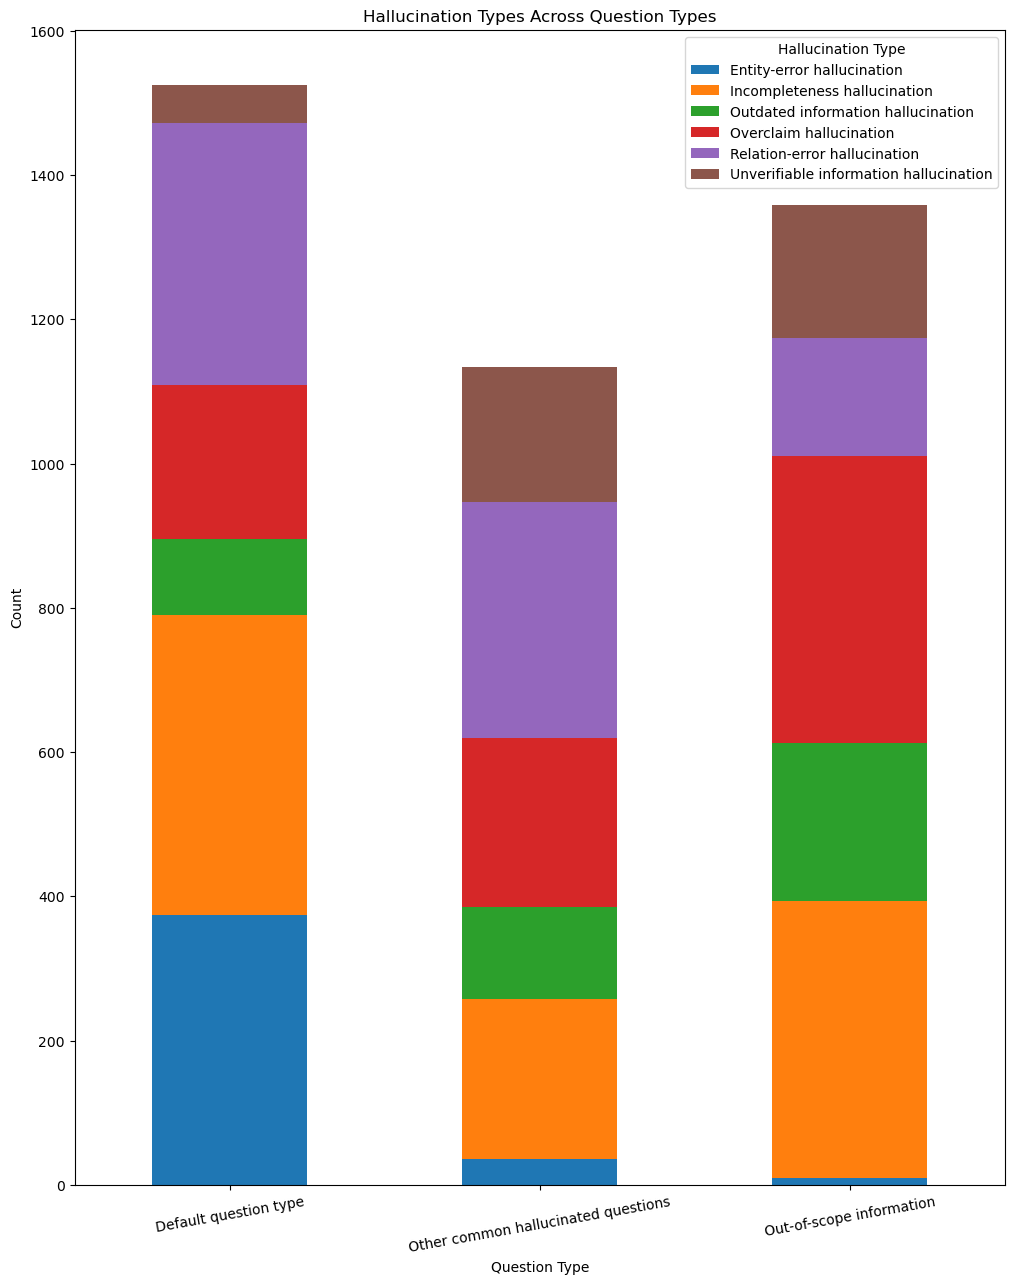

In [43]:
question_vs_hallucination = pd.crosstab(
    df["question_type"],
    df["hallucination_type_realized"]
)

question_vs_hallucination.plot(
    kind="bar",
    stacked=True,
    figsize=(12,15)
)

plt.title("Hallucination Types Across Question Types")

plt.xlabel("Question Type")
plt.ylabel("Count")

plt.xticks(rotation=10)

plt.legend(title="Hallucination Type",
           loc = "upper right")

plt.show()

### Heatmap of Hallucination Type Encouraged VS the Hallucination Type Realized

This is useful as it tells us the relationship between what kind of hallucination the prompt was designed to encourage vs what kind of hallucination the model actually produced. May tell us which hallucination types are easier to induce, etc.

Text(0, 0.5, 'Encouraged Hallucination Type')

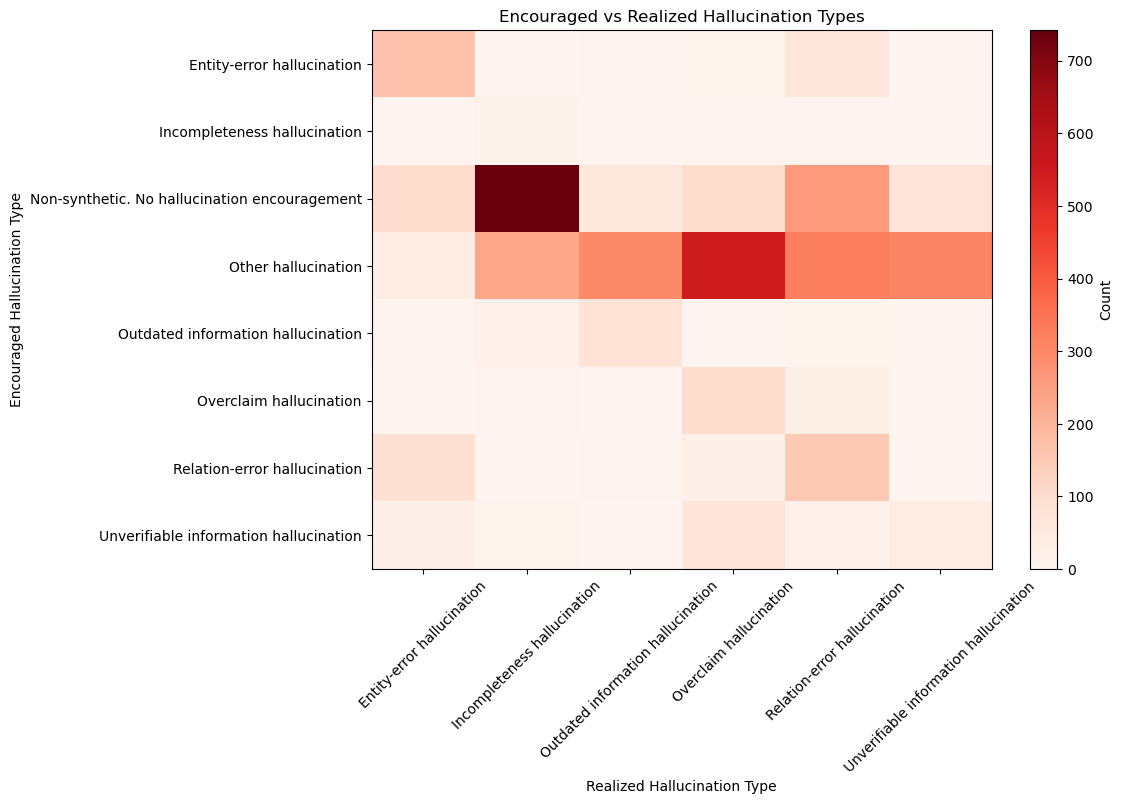

In [44]:
heatmap_data = pd.crosstab(
    df["hallucination_type_encouraged"],
    df["hallucination_type_realized"]
)

plt.figure(figsize=(10,7))

plt.imshow(heatmap_data, cmap='Reds', aspect='auto')

plt.colorbar(label='Count')

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Encouraged vs Realized Hallucination Types")
plt.xlabel("Realized Hallucination Type")
plt.ylabel("Encouraged Hallucination Type")